# Modulo 3

## Contexto & Objetivo:
* Contexto: Crear una herramienta para que el equipo de ventas envíe notificaciones push y así incentivar la compra de productos específicos
* Objetivo: Desarrollar un modelo que prediga si un usuario compraría un producto determinado en un momento dado

In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from typing import Tuple

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, auc
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("fast")

## Leemos los datos

In [2]:
# Carga los datos
df = pd.read_csv('../data/sampled_box_builder_df.csv')

Gestion de columnas:
* separamos en columnas informativas (fechas y id) (que no vamos a utilizar)
* label_col = outcome , que es la variable que queremos predecir
* Luego entre variables categoricas (que tienen mas de dos categorias)/binarias (2 categorias; que separamos en 0,1)/numericas
* Las categoricas necesitan encoding

In [3]:
df.columns

Index(['variant_id', 'product_type', 'order_id', 'user_id', 'created_at',
       'order_date', 'user_order_seq', 'outcome', 'ordered_before',
       'abandoned_before', 'active_snoozed', 'set_as_regular',
       'normalised_price', 'discount_pct', 'vendor', 'global_popularity',
       'count_adults', 'count_children', 'count_babies', 'count_pets',
       'people_ex_baby', 'days_since_purchase_variant_id',
       'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id',
       'days_since_purchase_product_type', 'avg_days_to_buy_product_type',
       'std_days_to_buy_product_type'],
      dtype='object')

In [4]:
info_cols = ["variant_id", "order_id", "user_id", "created_at", "order_date"]
label_col = "outcome"
features_cols = [col for col in df.columns if col not in info_cols + [label_col]]

categorical_cols = ["product_type", "vendor"]
binary_cols = ["ordered_before", "abandoned_before", "active_snoozed", "set_as_regular"]
numerical_cols = [col for col in df.columns if col not in categorical_cols + binary_cols]

### Filtramos los datos
Solo nos interesa cestas de almenos 5 articulos por rentabilidad de envío.
Lo hacemos con una funcion auxiliar:
* Una restingue solo en las compras mayores de 5
* la otra combierte las fechas en datatime de pandas
* luego con pipe hacemos que haga por orden las dos funciones

In [3]:
def push_relevant_dataframe(df: pd.DataFrame, min_products: int=5) -> pd.DataFrame:
    # Calculamos cuántos productos se compraron REALMENTE en cada pedido (sumando los 1s de outcome)
    df['real_purchase_size'] = df.groupby('order_id')['outcome'].transform('sum')

    # Filtramos por pedidos donde se compraron 5 o más cosas
    return df[df['real_purchase_size'] >= min_products].copy()

def format_data_columns(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .assign(created_at=lambda x: pd.to_datetime(x.created_at))
        .assign(order_date=lambda x: pd.to_datetime(x.order_date).dt.date)
    )
df_selected = (
    df
    .pipe(push_relevant_dataframe)
    .pipe(format_data_columns)
)

In [8]:
print(f"Filas originales: {len(df)}")
print(f"Filas tras filtrar por COMPRAS REALES: {len(df_selected)}")

Filas originales: 2880549
Filas tras filtrar por COMPRAS REALES: 2163953


### Hacemos el data split


In [4]:
daily_orders = df_selected.groupby("order_date").order_id.nunique()

Text(0.5, 1.0, 'Daily Orders')

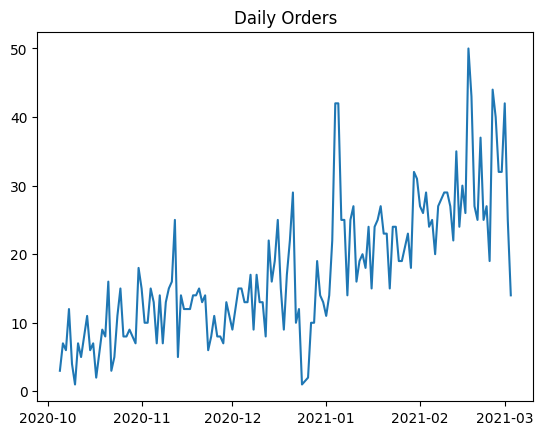

In [7]:
plt.plot(daily_orders, label="daily orders")
plt.title("Daily Orders")

Como vemos que el negocio a ido aumentando y que es un negocio cambiante, creciente, pensando en los datos que tendremos en produccion, para no sufrir de "information leakige" suponemos que solo usaremos datos del pasado. Por tanto quizas es interesante realizar un temporaly split, para asegurarnos que el modelo no entreno con datos del futuro y que a la hora de validar los nuevos datos sean del futuro, con nuevos productos, nuevas modas,...

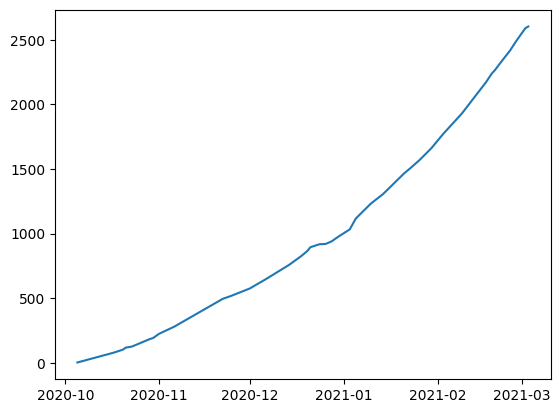

In [11]:
plt.plot(daily_orders.cumsum())

In [5]:
cumsum_daily_orders = daily_orders.cumsum() / daily_orders.sum()

train_val_cutoff = cumsum_daily_orders[cumsum_daily_orders <= 0.7].idxmax()
val_test_cutoff = cumsum_daily_orders[cumsum_daily_orders <= 0.9].idxmax()

In [6]:
# Ahora dividimos los datos 
train_df = df_selected[df_selected.order_date <= train_val_cutoff]
val_df = df_selected[
    (df_selected.order_date > train_val_cutoff) 
    & (df_selected.order_date <= val_test_cutoff)
]
test_df = df_selected[df_selected.order_date > val_test_cutoff]

## Baseline
* Hacemos un modelo base con el que comparar si es mejor o peor los modelos que vayamos probando. Y en cuanto.
* Baseline recomendado: usar solo global_popularity 
* Tambien decido la metrico que uso para comprar modelos: curva ROC y curva Precision-recall

In [7]:
def plot_metrics(
        model_name,
        y_pred,
        y_test,
        target_precision: float = 0.05,
        figure: Tuple[matplotlib.figure.Figure, np.array] = None,
):
    precision_, recall_, _ = precision_recall_curve(y_test, y_pred) # ignoramos el 3 valor que nos devuelve con el _
    pr_auc = auc(recall_, precision_) # Calculamos la area under the curve

    fpr, tpr, _ = roc_curve(y_test, y_pred) #con esto calculamos el False Positve Rate y el True Positive Rate
    roc_auc = roc_auc_score(y_test, y_pred)

    if figure is None:
        fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    else:
        fig, ax = figure

    ax[0].plot(recall_, precision_, label=f"{model_name}: AUC: {pr_auc:.2f}")
    ax[0].set_xlabel("recall")
    ax[0].set_ylabel("precision")
    ax[0].set_title(f"Precision-recall Curve")
    ax[0].legend()

    ax[1].plot(fpr, tpr, label=f"AUC: {roc_auc:.2f}")
    ax[1].set_xlabel("FPR")
    ax[1].set_ylabel("TPR")
    ax[1].set_title(f"ROC Curve")
    ax[1].legend()



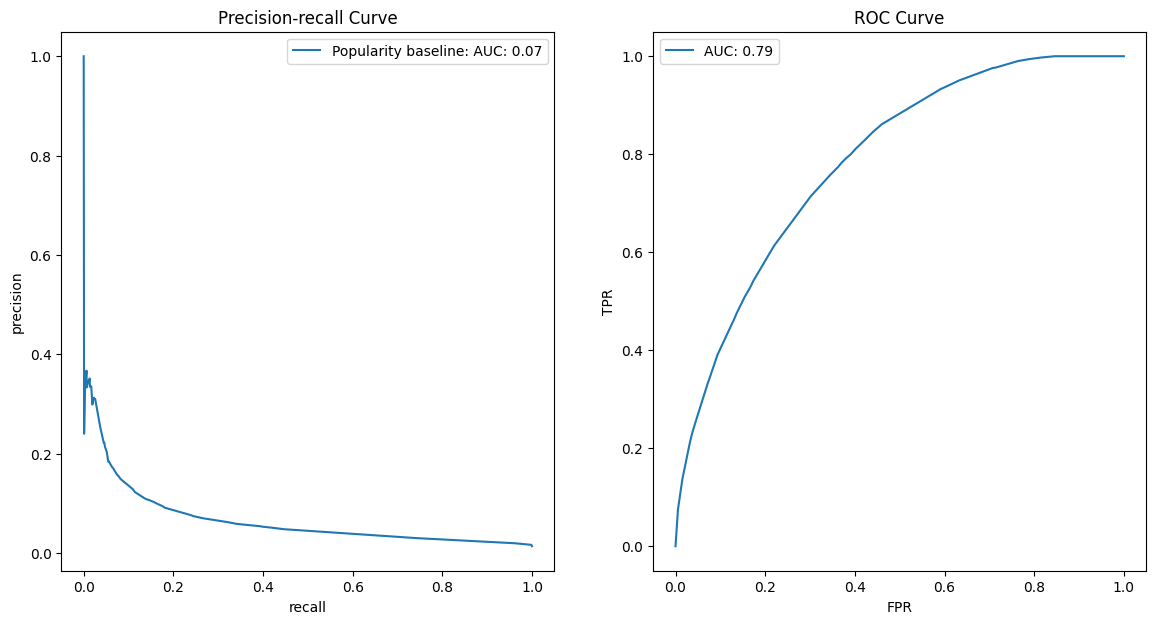

In [15]:
plot_metrics(
    "Popularity baseline", y_pred=val_df["global_popularity"], y_test=val_df[label_col]
)

## Model training
* Ridge regresion (cambiando alfas)
* Lasso regresion (cambiando alfas)

In [9]:
label_col = "outcome"
def feature_label_split(
    df: pd.DataFrame, label_col: str 
) -> Tuple[pd.DataFrame, pd.Series]:
    return df.drop(label_col, axis=1), df[label_col]

X_train, y_train = feature_label_split(train_df, label_col)
X_val, y_val = feature_label_split(val_df, label_col)
X_test, y_test = feature_label_split(test_df, label_col)

In [17]:
train_cols = numerical_cols + binary_cols
train_cols = [col for col in train_cols if col != "outcome"]

Comment: Al usar todos los datos el programa me petaba en el for. Por eso al final he decidido usar solo los datos que en el EDA vi que eran importantes y que en clase también concluimos que eran suficienes (más adelante veremos la comprovación). Los cuales son "ordered_before","abandoned_before", "global_popularity". Añadi 3 columnas más relativamente importantes en Ridge por si acasó y para que haya un poco de variedad.

In [12]:
train_cols = ["ordered_before","abandoned_before", "global_popularity", "set_as_regular", "active_snoozed", "normalised_price"]

## Ridge regression

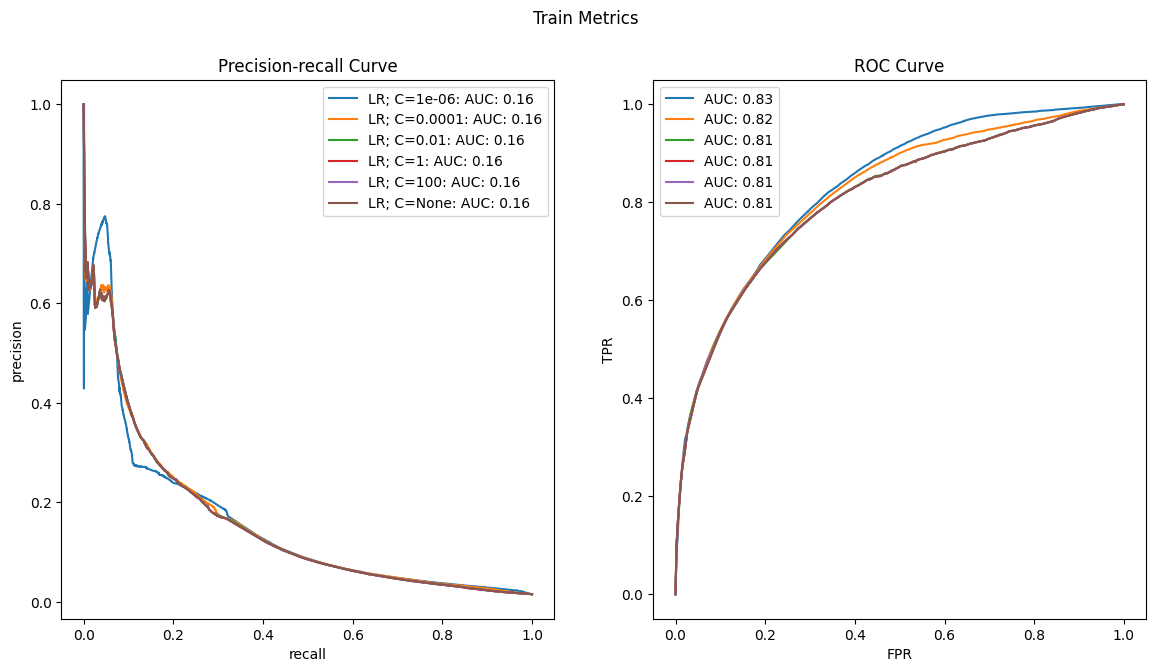

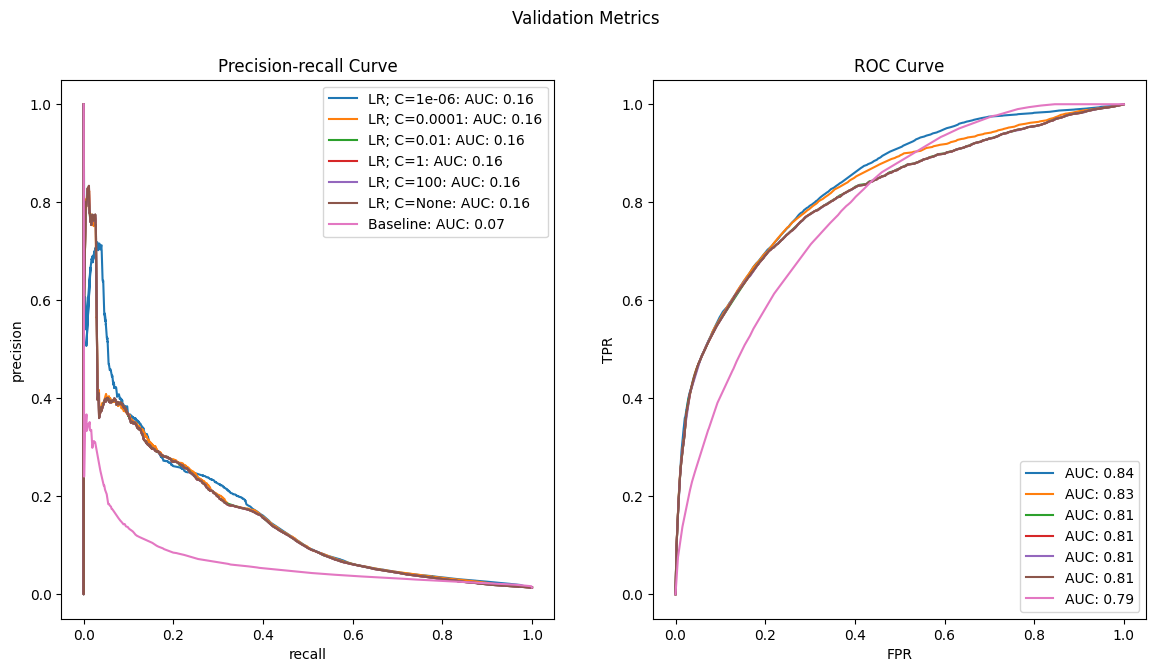

In [20]:
# 1. Inicialización de listas para guardar métricas
lr_push_train_aucs = []
lr_push_val_aucs = []
lr_push_train_ce = []
lr_push_val_ce = []


# 2. Definición de la rejilla de parámetros (Regularización inversa)
# Valores de C: desde mucha regularización (1e-8) hasta casi ninguna (1e4)
cs = [1e-6, 1e-4, 1e-2, 1, 100, None] # = 1 / alfa

# 3. Preparación de figuras para visualización
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Train Metrics")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
fig2.suptitle("Validation Metrics")

# 4. Bucle de entrenamiento y evaluación
for c in cs:
    # Creamos un pipeline que normaliza datos y aplica Regresión Logística (L2 = Ridge)
    # Si c es None, usamos C=1.0 (valor por defecto)
    lr = make_pipeline(
        StandardScaler(), # normalizo los datos con media 0 y var 1
        LogisticRegression(
            penalty="l2", # Indica que tiene regularizacion tipo Ridge
            C=c if c else 1.0, 
            max_iter=1000
        )
    )
    
    # Entrenamiento
    lr.fit(X_train[train_cols], y_train)
    
    # Cálculo de probabilidades para la clase 1 (compra)
    train_proba = lr.predict_proba(X_train[train_cols])[:, 1]
    plot_metrics(
        f"LR; C={c}", y_pred=train_proba, y_test=train_df[label_col], figure=(fig1, ax1)
    )
    val_proba = lr.predict_proba(X_val[train_cols])[:, 1]
    plot_metrics(
        f"LR; C={c}", y_pred=val_proba, y_test=val_df[label_col], figure=(fig2, ax2)
    )

plot_metrics(
    f"Baseline", 
    y_pred=val_df["global_popularity"], 
    y_test=val_df[label_col], 
    figure=(fig2, ax2)
)

Comment: 
* Mejoramos el baseline.
* No hay mucho cambio si modificamos la regularización. Porque al haber un dataset muy grande eso ya actua como regularización
* No cambia mucho el area bajo entre el training y el validation, poco overfitting.

## Lasso Regression

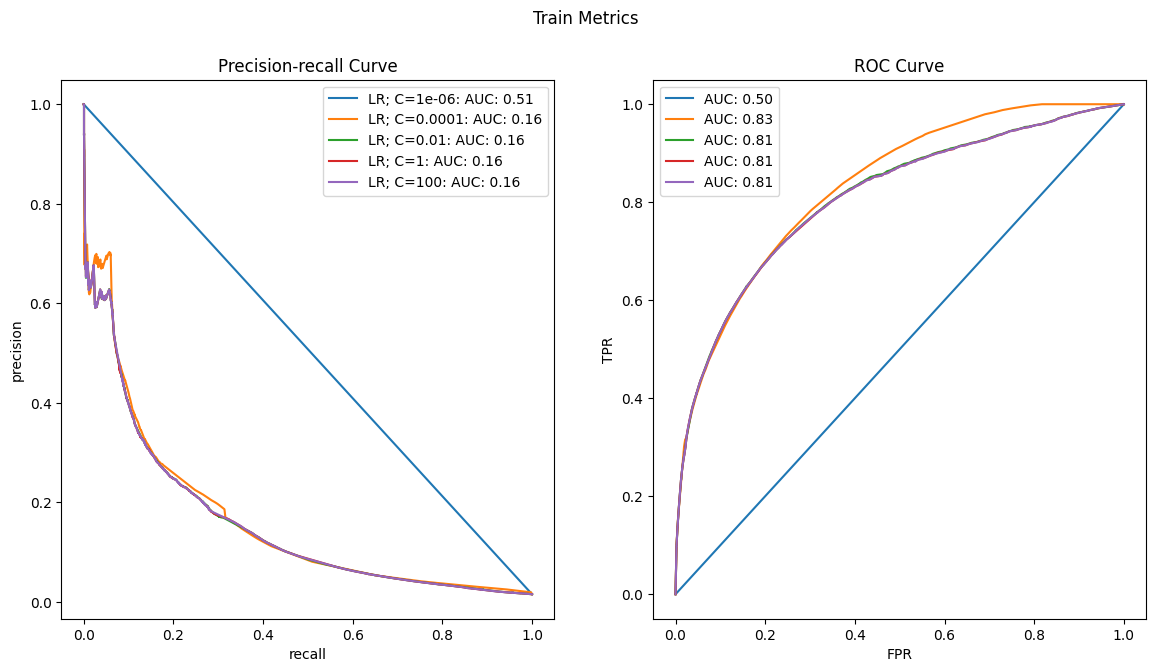

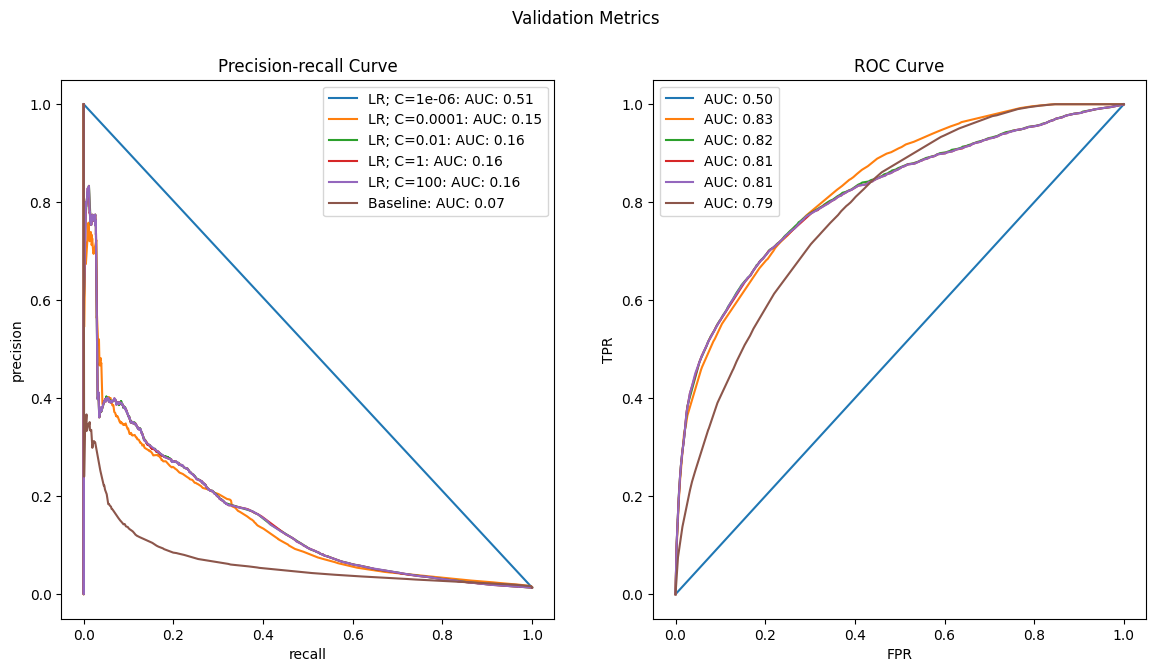

In [21]:
# 1. Inicialización de listas para guardar métricas
lr_push_train_aucs = []
lr_push_val_aucs = []
lr_push_train_ce = []
lr_push_val_ce = []


# 2. Definición de la rejilla de parámetros (Regularización inversa)
# Valores de C: desde mucha regularización (1e-8) hasta casi ninguna (1e4)
cs = [1e-6, 1e-4, 1e-2, 1, 100] # = 1 / alfa

# 3. Preparación de figuras para visualización
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Train Metrics")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
fig2.suptitle("Validation Metrics")

# 4. Bucle de entrenamiento y evaluación
for c in cs:
    # Creamos un pipeline que normaliza datos y aplica Regresión Logística (L2 = Ridge)
    # Si c es None, usamos C=1.0 (valor por defecto)
    lr = make_pipeline(
        StandardScaler(), # Si no normalizo a la hora de ajustar los pesos esto puede verse afectado al poner pesos muy pequeños a varibles grandes y vicebersa
        LogisticRegression(
            penalty="l1", # Indica que tiene regularizacion tipo Lasso
            solver="liblinear", # necesario para L1
            C=c if c else 1.0, 
            max_iter=1000
        )
    )
    
    # Entrenamiento
    lr.fit(X_train[train_cols], y_train)
    
    # Cálculo de probabilidades para la clase 1 (compra)
    train_proba = lr.predict_proba(X_train[train_cols])[:, 1]
    plot_metrics(
        f"LR; C={c}", y_pred=train_proba, y_test=train_df[label_col], figure=(fig1, ax1)
    )
    val_proba = lr.predict_proba(X_val[train_cols])[:, 1]
    plot_metrics(
        f"LR; C={c}", y_pred=val_proba, y_test=val_df[label_col], figure=(fig2, ax2)
    )
    
plot_metrics(
    f"Baseline", 
    y_pred=val_df["global_popularity"], 
    y_test=val_df[label_col], 
    figure=(fig2, ax2)
)

Comments:
* Resultados muy parecidos
* Si hacemos muy grande la c es decir muy pequeña la regularizacion obtenemos una linea que realmente son 2 puntos. Porque se lleva todo a 0, y es 1 Recall y 0 precision o al reves.

## Coefficients weights

In [25]:
# ejecutamos ridge otra vez y nos quedamos con los coficientes.
lr = Pipeline(
    [
        ("standard_scaler", StandardScaler()),
        ("lr", LogisticRegression(penalty="l2", C=1e-6))
    ]
)
lr.fit(X_train[train_cols], y_train)
lr_coef_l2 = pd.DataFrame(
    {
        "features": train_cols,
        "importance": np.abs(lr.named_steps["lr"].coef_[0]),
        "regularisation": ["l2"]*len(train_cols)
    }
)
lr_coef_l2 = lr_coef_l2.sort_values("importance", ascending=True)

# ejecutamos ahora lasso
lr = Pipeline(
    [
        ("standard_scaler", StandardScaler()),
        ("lr", LogisticRegression(penalty="l1", solver="liblinear", C=1e-4))
    ]
)
lr.fit(X_train[train_cols], y_train)
lr_coef_l1 = pd.DataFrame(
    {
        "features": train_cols,
        "importance": np.abs(lr.named_steps["lr"].coef_[0]),
        "regularisation": ["l1"]*len(train_cols)
    }
)
lr_coef_l1 = lr_coef_l1.sort_values("importance", ascending=True)




<Axes: xlabel='importance', ylabel='features'>

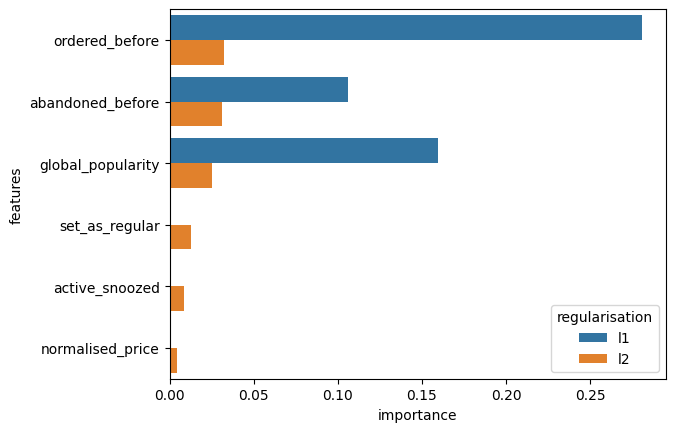

In [27]:
lr_coefs = pd.concat([lr_coef_l2, lr_coef_l1])
lr_coefs["features"] = pd.Categorical(lr_coefs["features"])
lr_coefs = lr_coefs.sort_values(by=["importance"])
order_columns = lr_coef_l2.sort_values(by="importance", ascending=False)["features"]
sns.barplot(
    data=lr_coefs,
    x="importance",
    y="features",
    hue="regularisation",
    order=order_columns
)

Insights:
* Podemos observar que Lasso lleva a 0 las variables se_as_regular, active_snoozed y normalised_price. Y da mucho peso a los valores que ya esperabamos que fueran importantes. Esto nos puede indicar que quizas con solo esas variables, tiene suficiente poder predictivo. Siempre que podamos simplificar el model lo haremos.
* Haría falta probar de modelar solo con esas tres variables para acabar de comprobar.

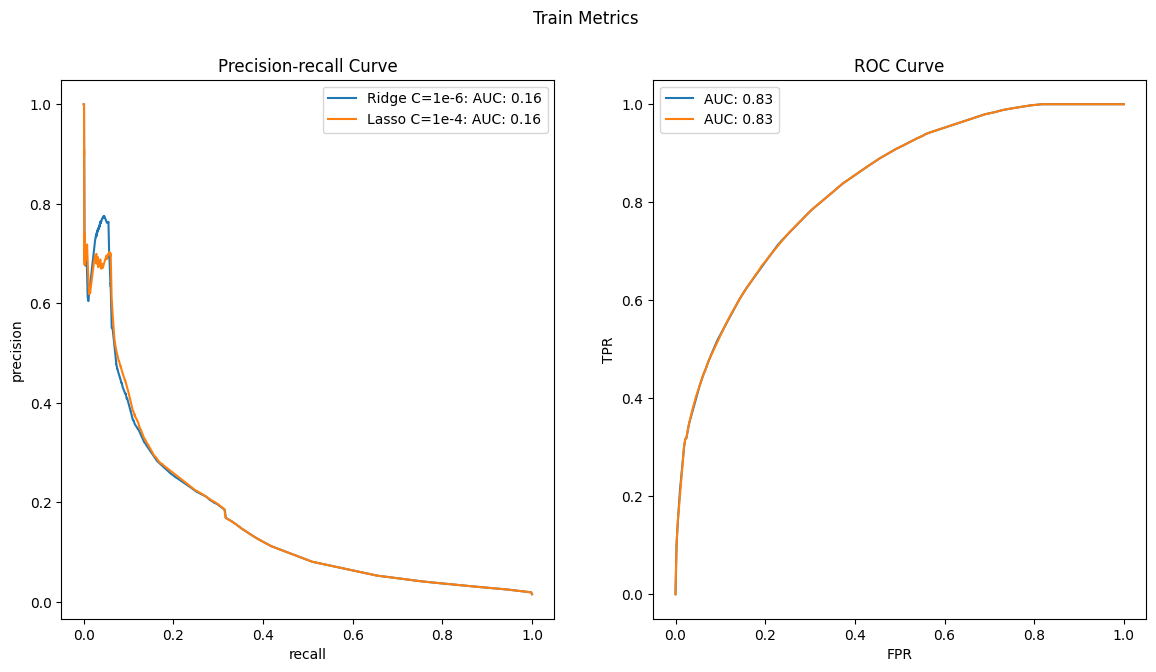

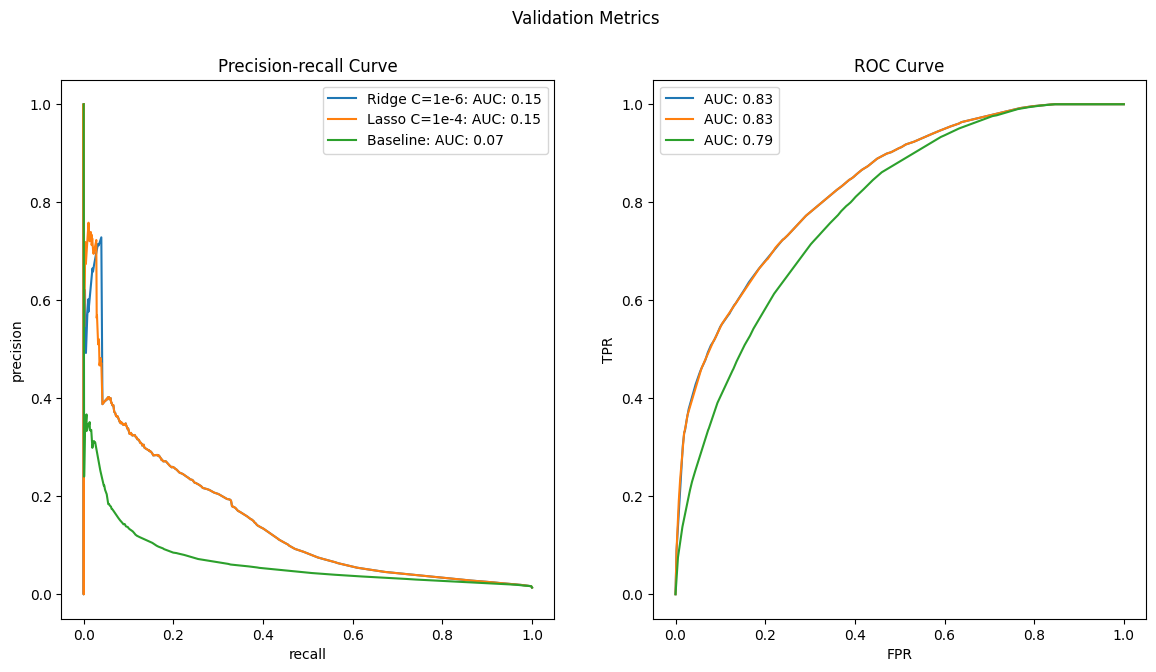

In [15]:
reduced_cols = ["ordered_before","abandoned_before", "global_popularity"]
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Train Metrics")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
fig2.suptitle("Validation Metrics")

lrs = [
    make_pipeline(StandardScaler(), LogisticRegression(penalty="l2", C=1e-6)),
    make_pipeline(StandardScaler(), LogisticRegression(penalty="l1", C=1e-4, solver="liblinear"))
]

names = ["Ridge C=1e-6", "Lasso C=1e-4"]
for name, lr in zip(names, lrs):
    lr.fit(X_train[reduced_cols], y_train)
    train_proba = lr.predict_proba(X_train[reduced_cols])[:,1] # todas las filas, columna 1
    plot_metrics(name, y_pred=train_proba, y_test=train_df[label_col], figure=(fig1, ax1))
    val_proba = lr.predict_proba(X_val[reduced_cols])[:,1]
    plot_metrics(name, y_pred=val_proba, y_test=val_df[label_col], figure=(fig2, ax2))

plot_metrics(
    f"Baseline",
    y_pred=val_df["global_popularity"],
    y_test=val_df[label_col],
    figure=(fig2,ax2)
)


Comment: 
* Vemos que AUC es igual que antes (0,15 y 0,83), por lo que evidencia que es suficinete usar esos tres valores solo.
* En este caso como ya he mencionado esta comprovación no era tan necesaria debido a que de primeras ya defini el problema usando solo 6 variables. Es posible que los cambios no sean tan significativo pq solo he eliminado 3 de las 6. 

## Categorical Encoding

* Añadimos ahora las variables categoricas, haciendo las deformaciones necesarias para poder aplicarlas con un pipeline. Aplicamos un calumnTransformer, que a las numericas, "passthrough" no les hace nada y las categoricas hacer el categorical_preprocesor, en la cual hemos añaido las transformaciones que queramos ("drop", OrdinalEncoder, OneHotEncoder, HashEncoder, TragetEncoder,...) 
* Volvemos a entrenar los modelos ahora con esas variables. Si mejoran el model ok, nos quedamos con el pipelane entero y con las nuevas variabes. Si no, pues nos quedamos con el anterior. 
* Makepipeline: preprocesor, StandarScaler y luego el LogisticalRegression.


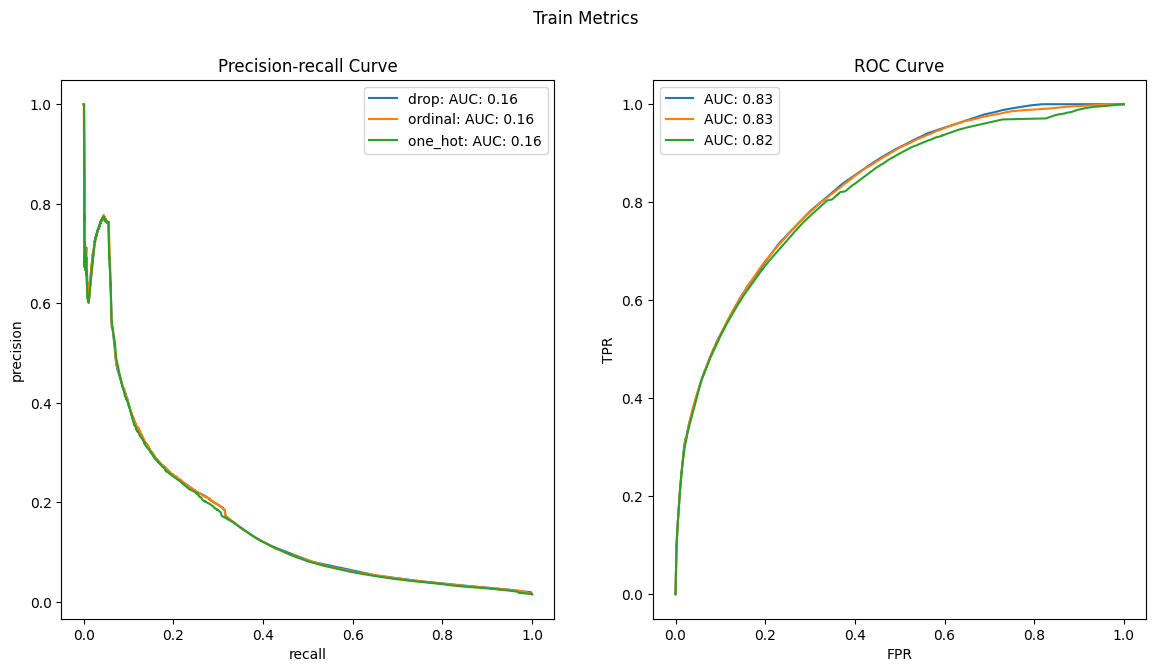

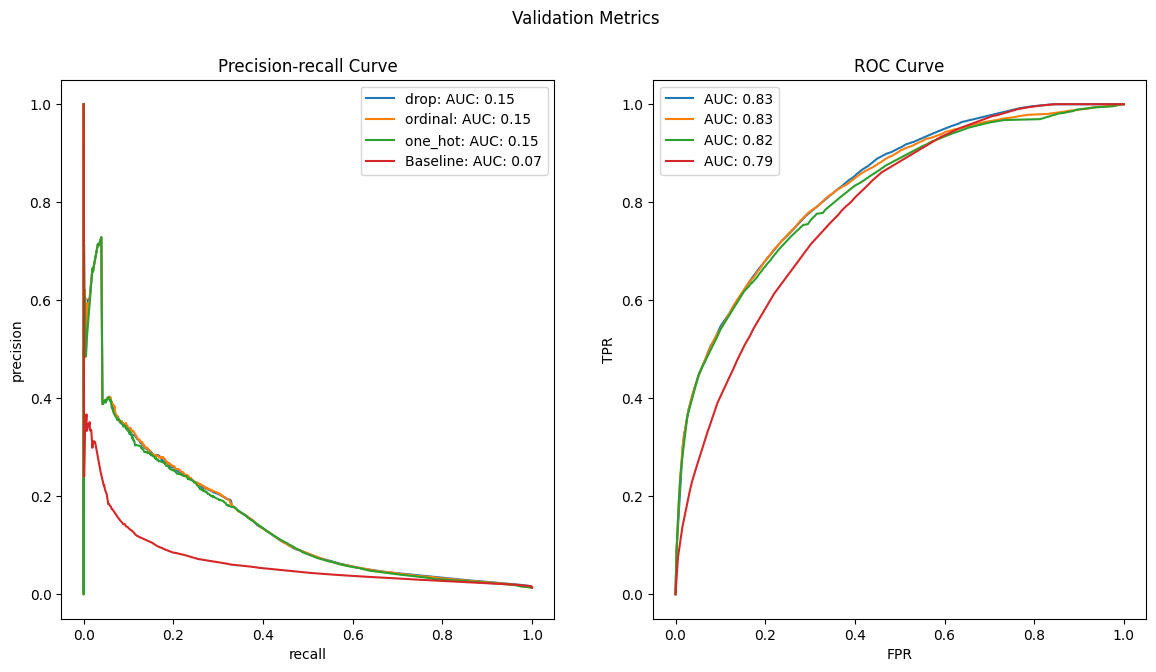

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Train Metrics")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
fig2.suptitle("Validation Metrics")

label_col = "outcome"
reduced_cols = ["ordered_before","abandoned_before", "global_popularity"]
categorical_cols = ["product_type", "vendor"]

extended_cols = reduced_cols + categorical_cols

categorical_preprocessors = [
    ("drop", "drop"),

    ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),

    ("one_hot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        max_categories=20   # opcional
    )),
]

results = {}

for name, cat_preprocessor in categorical_preprocessors:

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", reduced_cols),
            ("cat", cat_preprocessor, categorical_cols)
        ]
    )

    lr = make_pipeline(
        preprocessor,
        StandardScaler(),
        LogisticRegression(penalty="l2", C=1e-6, max_iter=1000)
    )

    lr.fit(X_train[extended_cols], y_train)

    train_proba = lr.predict_proba(X_train[extended_cols])[:, 1]
    plot_metrics(
        name,
        y_pred=train_proba,
        y_test=train_df[label_col],
        figure=(fig1, ax1)
    )

    val_proba = lr.predict_proba(X_val[extended_cols])[:, 1]
    plot_metrics(
        name,
        y_pred=val_proba,
        y_test=val_df[label_col],
        figure=(fig2, ax2)
    )

plot_metrics(
    "Baseline",
    y_pred=val_df["global_popularity"],
    y_test=val_df[label_col],
    figure=(fig2, ax2)
)

Comment:
* Mejoran el baseline, pero no lo suficiente.
* Podemos ver que no se encuentra ninguna mejoria significativa respecto a los modelos lineales de Ridge y Lasso sin las categoricas y con solo las 3 variables clave. Por lo que nos quedaremos con el modelo sin coger variables categoricas

## Siguiente objetivo o milestone:
*Pasarlo a produccion, con un scrip de training y un script de inference